# Simulazione Dinamica di Segregazione
Per studiare l'emergere della polarizzazione dalle scelte individuali dei singoli nodi, abbiamo realizzato una simulazione basata sul Schelling Segregation Model.
Il modello parte da una rete che mantiene la nostra distribuzione di grado e ne fa evolvere gli archi, in modo da non alterare i gradi dei singoli nodi.
Ad ogni step ogni nodo della rete valuta se cambiare un proprio link paragonando la frazione di nodi simili a cui è connesso con la soglia di soddisfazione. Quindi cercherà un nodo simile e disponibile a cui connettersi.
Per mantenere inalterata la distribuzione di grado l'operazione di rewire può essere schematizzata come segue:
$$(A,B);(C,D) \implies (A,C);(B,D)$$
I nodi $A,B,C,D$ sono scelti rispettando i criteri:
- $A$ è un nodo insoddisfatto
- $B$ è connesso ad $A$, ma appartenente ad una classe diversa
- $C$ non è connesso ad $A$, ma appartente alla stessa classe
- $D$ è un nodo generico connesso con $C$, ma non connesso a $B$

*Questo modello è in grado di riprodurre i valori di polarizzazione osservati nella rete?*

*Per quali valori della soglia di soddisfazione i parametri, che misurano la polarizzazione della rete, raggiungono i valori osservati?*

*Si osserva la tendenza dei nodi a dividersi in gruppi separati, anche per soglie di soddisfazione fortemente minori del 50%?*

In [1]:
import igraph as ig 
import numpy as np
import matplotlib.pyplot as plt
from sys import stdout

from segregation_model import segregation_sim, satisfaction
from lorenzo_utils import *

G = load_graph(DATA_DIR+'immigration_23.graphml')
attr_map = np.array([1 if v == 'A' else 0 for v in G.vs['group']])
nodes = nodes_all(G)
nodes_satisfaction = np.array([satisfaction(n,G.neighbors(n),G.vs['group']) for n in nodes])

In [5]:
treshold = 0.5
ei_obs = ei_index(G, attr_map)
cross_fraction_obs = 1-cross_type_fraction(G, attr_map)
satisfaction_rate_obs = nodes_satisfaction[nodes_satisfaction >= treshold].size / nodes.size
segregation_index_obs = np.mean(nodes_satisfaction)
ei_index_sim = []
cross_fraction_sim = []
satisfaction_rate_sim = []
segregation_index_sim = []
print('target simulazione: EI =', round(ei_obs,4), '   Fraction =', round(cross_fraction_obs,4), '\n')
stdout.flush()
for G_sim, statistic in segregation_sim(G,treshold, max_satisfaction=0.98):
    ei_index_sim.append(ei_index(G_sim, attr_map))
    cross_fraction_sim.append(1-cross_type_fraction(G_sim, attr_map))
    satisfaction_rate_sim.append(statistic['satisfaction_rate'])
    segregation_index_sim.append(statistic['segregation_index'])
    if statistic['i_step']:
        print(f'Segregation Model Step {statistic['i_step']}')
        print(f'Changed {statistic['nodes_changed_step']} nodes with {statistic['rewires_step']} rewires')
        trys = statistic['nodes_failures_step']+statistic['nodes_changed_step']
        # print(f'Failed for', statistic['nodes_failures_step'], 'nodes    success:', 
        #     statistic['nodes_changed_step']*100/trys if trys else 100, '%')
        print('Satisfaction:', statistic['satisfaction_rate'], '    Index:', statistic['segregation_index'])
    if not statistic['i_step']:
        print('Simulation started with:', end='')
    print('EI =', round(ei_index_sim[-1],4),
        '   Fraction =', round(cross_fraction_sim[-1],4),'\n')
    stdout.flush()

if not statistic['nodes_changed_step']:
    print('Simulation ended in a stable configuration at step', statistic['i_step'])
    print('Total failures', len(list(filter(lambda x: x>0, statistic['nodes_failures']))))
else:
    print('Simulation stopped at satisfaction rate of:', statistic['satisfaction_rate']*100, '%')

target simulazione: EI = -0.934    Fraction = 0.967 

Simulation started with:EI = -0.0085    Fraction = 0.5042 

Segregation Model Step 1
Changed 3716 nodes with 3716 rewires
Satisfaction: 0.6096228595440698     Index: 0.5398818080407302
EI = -0.1519    Fraction = 0.576 

Segregation Model Step 2
Changed 1363 nodes with 1363 rewires
Satisfaction: 0.8568126904086564     Index: 0.7409968167127969
EI = -0.187    Fraction = 0.5935 

Segregation Model Step 3
Changed 807 nodes with 807 rewires
Satisfaction: 0.9152221872045383     Index: 0.7777252980163029
EI = -0.2053    Fraction = 0.6026 

Segregation Model Step 4
Changed 574 nodes with 574 rewires
Satisfaction: 0.9396995482718773     Index: 0.7907098034829565
EI = -0.2166    Fraction = 0.6083 

Segregation Model Step 5
Changed 419 nodes with 419 rewires
Satisfaction: 0.9559827712995063     Index: 0.7991561044466112
EI = -0.2264    Fraction = 0.6132 

Segregation Model Step 6
Changed 377 nodes with 377 rewires
Satisfaction: 0.9603949994747

In [ ]:
dump = {
    'file': 'immigration_23.graphml',
    'treshold': treshold,
    'ei_obs': ei_obs,
    'cross_fraction_obs': cross_fraction_obs,
    'satisfaction_rate_obs': satisfaction_rate_obs,
    'segregation_index_obs':segregation_index_obs,
    'ei_index_sim': ei_index_sim,
    'cross_fraction_sim': cross_fraction_sim,
    'satisfaction_rate_sim': satisfaction_rate_sim,
    'segregation_index_sim': segregation_index_sim
}
import json
json.dump(dump, open(f'dump_segregation_immigration_23_{int(treshold*100)}.json', 'w'))

Per visualizzare lo stato della simulazione abbiamo usato quattro metriche:
- e_i index: ${i_A + i_B -e \over i_A + i_B + e}$

dove $i_A$ e $i_B$ sono i link interni alle comunità e $e$ sono i link ponte tra le comunità

- cross fraction: frazione di link tra comunità rispetto ai link totali della rete

- satisfaction rate: frazione dei nodi soddisfatti in accordo con la soglia selezionata in partenza

- segregation index: frazione media di nodi simili per ogni nodo

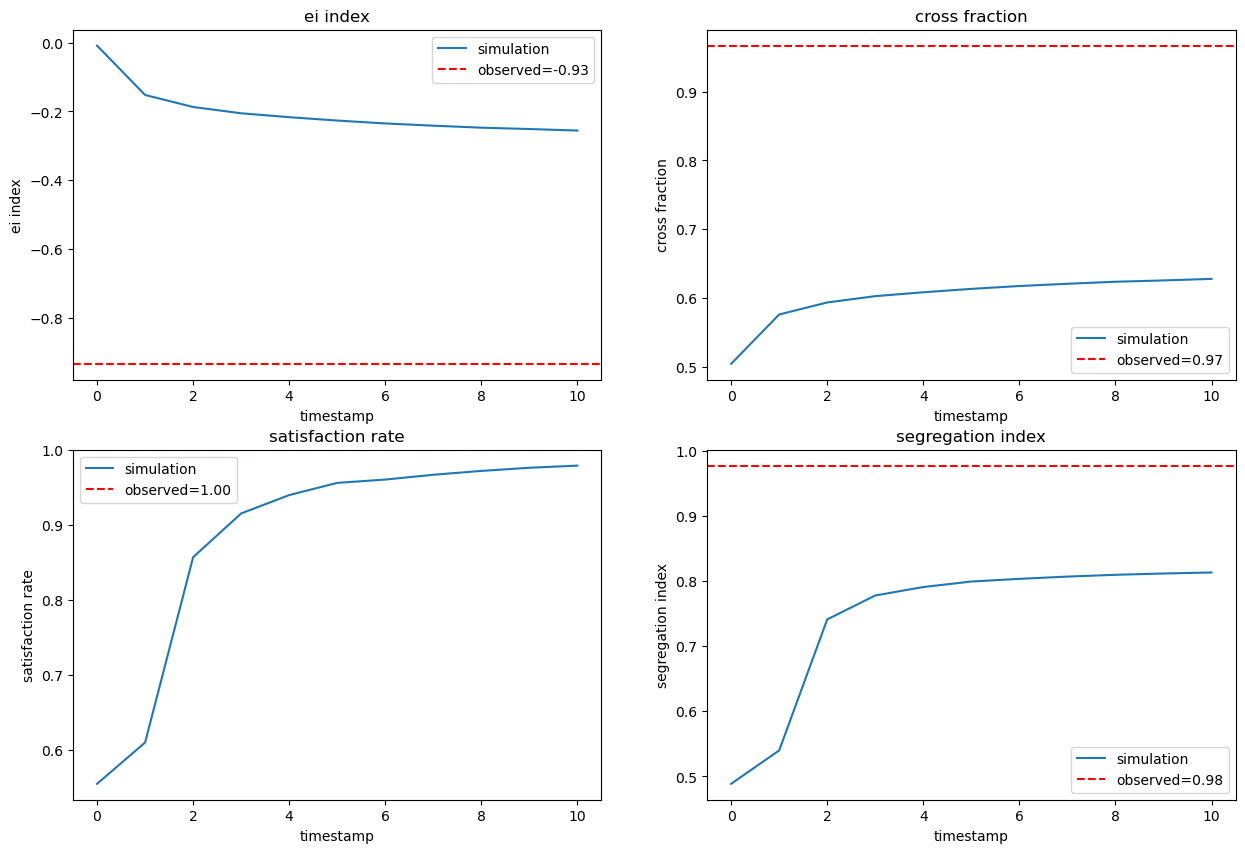

In [6]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

time_st = range(len(ei_index_sim))
simulation = [ei_index_sim, cross_fraction_sim, satisfaction_rate_sim, segregation_index_sim]
observed  = [ei_obs, cross_fraction_obs, satisfaction_rate_obs, segregation_index_obs]
titles = ['ei index', 'cross fraction', 'satisfaction rate', 'segregation index']

for ax, sim, obs, title in zip(axes.flat, simulation, observed, titles):
    ax.plot(time_st, sim, label='simulation')
    ax.set_xlabel('timestamp')
    ax.set_ylabel(title)
    ax.axhline(obs, color='red', linestyle='--', label=f'observed={obs:.2f}')
    ax.set_title(title)
    ax.legend()
    

# Conclusioni
Osserviamo come la simulazione converga ad uno stato stazionario ad ogni iterazione indipendentemente dalla soglia, riuscendo quindi a soddisfare tutti i nodi.

Per un'ampia scelta di valori della soglia di soddisfazione $[0.35,0.75]$ il valore finale dell'indice di segregazione rimane costantemente alto intorno all' $80\%$.
Mentre per essere in grado di riprodurre i valori osservati per tutte le metriche di controllo è necessario impostare una soglia molto alta di almeno $95\%$, che dimostra come le dinamiche che hanno generato la rete siano frutto della volontà degli individui di interagire con utenti simili.